# Modelos de Deep Learning: Aplicaciones prácticas

# **Tarea 1**



#**Análisis del Clasificador Lineal con TensorFlow**

En este ejercicio implementamos un modelo de aprendizaje automático básico llamado **clasificador lineal**. A continuación, se detalla su funcionamiento técnico:

**A. Parámetros del Modelo ($W$ y $b$)**

El modelo intenta encontrar la separación óptima entre dos grupos de datos mediante una función lineal. Los componentes clave son:

*   **Pesos ($W$ o "Weights"):** Representan la importancia de cada característica de entrada (en este caso, las coordenadas $x_1$ y $x_2$). Determinan la inclinación de la línea de decisión.
*   **Sesgo ($b$ o "Bias"):** Es un término independiente que permite desplazar la línea de decisión en el plano para que no necesariamente pase por el origen $(0,0)$.
*   **Ecuación**: La predicción se calcula como $z = x \cdot W + b$.

**B. La Lógica de Predicción**

Una vez calculada la ecuación, el modelo toma una decisión basada en un umbral (threshold):

*   Si el resultado del modelo es mayor a 0.5, el punto se asigna a la Clase 1 (Verde).
*   Si el resultado es menor a 0.5, el punto se asigna a la Clase 0 (Rojo).

La "línea de decisión" es precisamente el lugar geométrico donde el resultado es exactamente 0.5.

**C. Optimización mediante Descenso por Gradiente**

Para que el modelo "aprenda", utilizamos un ciclo de entrenamiento:


1.   **Cálculo del error:** Usamos la función de pérdida (MSE) para medir qué tan lejos están las predicciones de los valores reales
2.  **tf.GradientTape():** Esta herramienta de TensorFlow actúa como una "grabadora" que registra todas las operaciones matemáticas. Al finalizar, calcula automáticamente las derivadas (gradientes) del error respecto a $W$ y $b$.
3.   **Actualización:** El modelo ajusta $W$ y $b$ restándoles una fracción del gradiente (multiplicada por la tasa de aprendizaje o learning rate), logrando que en cada paso la línea de decisión se acerque más a la separación perfecta.










---
# PROBLEMA 1
## Clasificador lineal en TensorFlow

**Modificaciones solicitadas:**
1. Cambiar color del conjunto superior a verde y del inferior a rojo
2. Cambiar matriz de covarianza para que las nubes sean casi esféricas
3. Dibujar línea de decisión negra discontinua en lugar de roja

**Generando dos clases de puntos aleatorios en un plano 2D**

#**Paso 1: Generación de Datos (Nubes Esféricas)**
**Generación de nubes de datos casi esféricas:** Para lograr que las nubes sean casi esféricas (circulares en 2D), ajustamos la matriz de covarianza a [[0.2, 0.0], [0.0, 0.2]]. Al poner los valores de fuera de la diagonal en 0.0, eliminamos la correlación entre x1 y x2, evitando que las nubes se vean alargadas.

In [214]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
tf.random.set_seed(42)

num_samples_per_class = 1000
# Matriz de covarianza casi esférica: valores pequeños en la diagonal, casi cero fuera
cov_esferica = [[0.2, 0.0], [0.0, 0.2]]
negative_samples = np.random.multivariate_normal(
    mean=[0, 3], cov=cov_esferica, size=num_samples_per_class)
positive_samples = np.random.multivariate_normal(
    mean=[3, 0], cov=cov_esferica, size=num_samples_per_class)

**Apilando las dos clases en un array con forma (2000, 2)**

In [215]:
inputs = np.vstack((negative_samples, positive_samples)).astype(np.float32)

In [216]:
inputs.shape

(2000, 2)

**Generando los targets correspondientes (0 y 1)**

In [217]:
targets = np.vstack((np.zeros((num_samples_per_class, 1), dtype="float32"),
                     np.ones((num_samples_per_class, 1), dtype="float32")))

**Graficando las dos clases de puntos - Conjunto inferior (0) en ROJO, superior (1) en VERDE**

#**Paso 2: Asignación de Etiquetas y Colores**
**Clasificación y asignación de colores:** Asignamos la Clase 0 a la nube superior (Verde) y la Clase 1 a la nube inferior (Roja). Combinamos los datos en una sola matriz de entrada (inputs) y creamos el vector de etiquetas (targets) para el entrenamiento.

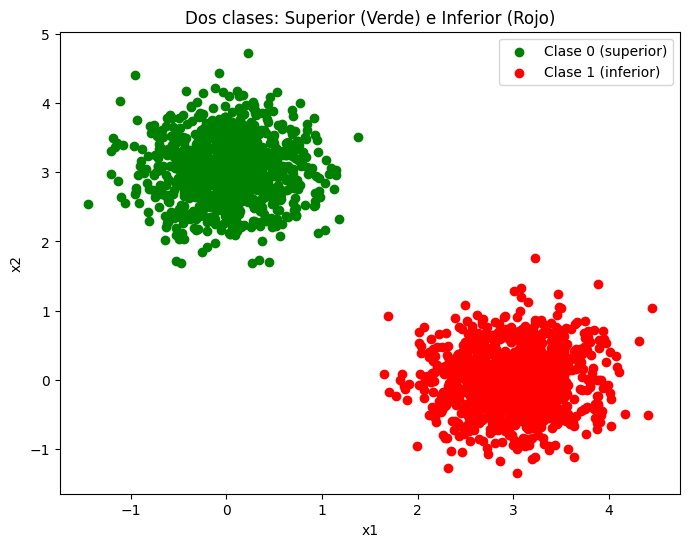

In [218]:
plt.figure(figsize=(8, 6))
mask0 = (targets[:, 0] == 0).flatten()
mask1 = (targets[:, 0] == 1).flatten()
plt.scatter(inputs[mask0, 0], inputs[mask0, 1], c='green', label='Clase 0 (superior)')
plt.scatter(inputs[mask1, 0], inputs[mask1, 1], c='red', label='Clase 1 (inferior)')
plt.legend()
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Dos clases: Superior (Verde) e Inferior (Rojo)')
plt.show()

**Creando las variables del clasificador lineal**

#**Paso 3: Entrenamiento con Descenso por Gradiente**
**Entrenamiento del Clasificador con tf.GradientTape():** Utilizamos el ciclo de entrenamiento para ajustar los Pesos (W) y el Sesgo (b). El modelo utiliza tf.GradientTape para registrar la pérdida y calcular los gradientes que permiten mover la línea de decisión hacia la posición óptima de separación.

In [219]:
input_dim = 2
output_dim = 1
W = tf.Variable(initial_value=tf.random.uniform(shape=(input_dim, output_dim)))
b = tf.Variable(initial_value=tf.zeros(shape=(output_dim,)))

**Función de forward pass**

In [220]:
def model(inputs):
    return tf.matmul(inputs, W) + b

**Función de pérdida (error cuadrático medio)**

In [221]:
def square_loss(targets, predictions):
    per_sample_losses = tf.square(targets - predictions)
    return tf.reduce_mean(per_sample_losses)

**Función de paso de entrenamiento**

In [222]:
learning_rate = 0.1

def training_step(inputs, targets):
    with tf.GradientTape() as tape:
        predictions = model(inputs)
        loss = square_loss(targets, predictions)
    grad_loss_wrt_W, grad_loss_wrt_b = tape.gradient(loss, [W, b])
    W.assign_sub(grad_loss_wrt_W * learning_rate)
    b.assign_sub(grad_loss_wrt_b * learning_rate)
    return loss

**Ciclo de entrenamiento por lotes**

In [223]:
for step in range(40):
    loss = training_step(inputs, targets)
    if step % 10 == 0:
        print(f"Loss at step {step}: {loss:.4f}")

Loss at step 0: 1.5210
Loss at step 10: 0.0286
Loss at step 20: 0.0261
Loss at step 30: 0.0240


**Graficando predicciones con LÍNEA DE DECISIÓN NEGRA DISCONTINUA**

#**Paso 4: Visualización de la Línea de Decisión**
**Resultado Final y Línea de Decisión:** Dibujamos la línea de decisión final. Como se solicitó, la línea es negra y discontinua ('k--'), logrando una separación clara entre la clase verde y la clase roja.


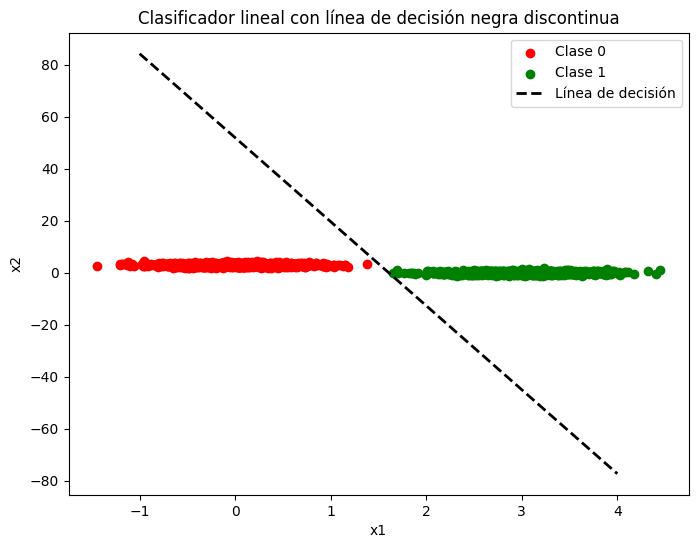

In [224]:
predictions = model(inputs)
w = W.numpy()
b_val = b.numpy()
x = np.linspace(-1, 4, 100)
y = -(w[0, 0] / w[1, 0]) * x + (0.5 - b_val[0]) / w[1, 0]

plt.figure(figsize=(8, 6))
mask0 = (targets[:, 0] == 0).flatten()
mask1 = (targets[:, 0] == 1).flatten()
plt.scatter(inputs[mask0, 0], inputs[mask0, 1], c='red', label='Clase 0')
plt.scatter(inputs[mask1, 0], inputs[mask1, 1], c='green', label='Clase 1')
plt.plot(x, y, 'k--', linewidth=2, label='Línea de decisión')
plt.legend()
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Clasificador lineal con línea de decisión negra discontinua')
plt.show()

---
# PROBLEMA 2
## Regresión lineal con tf.GradientTape()

Crear conjunto sintético de 100 puntos:
- x: rango [0, 10], distribución uniforme
- y: línea recta + ruido gaussiano (std=0.4)
- Resolver con descenso por gradiente usando tf.GradientTape()

#**Paso 1: Preparación de Datos**
### Generación del Conjunto de Datos: Creamos 100 puntos de datos con una distribución uniforme en x (rango [0, 10]) y añadimos ruido gaussiano (std=0.4) para simular un escenario real.


In [225]:
np.random.seed(42)
tf.random.set_seed(42)

n_points = 100
# x: distribución uniforme en [0, 10]
x_data = np.random.uniform(0, 10, size=(n_points, 1)).astype(np.float32)
# y: línea recta (ej: y = 2x + 1) + ruido gaussiano std=0.4
pendiente_real = 2.0
intercepto_real = 1.0
y_data = (pendiente_real * x_data + intercepto_real +
          np.random.normal(0, 0.4, size=(n_points, 1))).astype(np.float32)

#**Paso 2: Definición del Modelo**
Definición de Parámetros y Modelo: Definimos los pesos (W) y el sesgo (b) como variables entrenables. La predicción se calcula mediante la ecuación lineal $y = x \cdot W + b$.

In [226]:
# Parámetros entrenables
w_reg = tf.Variable(tf.random.uniform(shape=(1, 1)))
b_reg = tf.Variable(tf.zeros(shape=(1,)))

def regression_model(x):
    return tf.matmul(x, w_reg) + b_reg

def mse_loss(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred))

learning_rate_reg = 0.01
epochs = 500

#**Paso 3: Ciclo de Entrenamiento con tf.GradientTape()**
Implementamos el descenso por gradiente manual. Usamos la "cinta" de TensorFlow para calcular los gradientes del Error Cuadrático Medio (MSE) y actualizamos los parámetros en cada Epoch.

In [227]:
for epoch in range(epochs):
    with tf.GradientTape() as tape:
        y_pred = regression_model(x_data)
        loss = mse_loss(y_data, y_pred)
    gradients = tape.gradient(loss, [w_reg, b_reg])
    w_reg.assign_sub(gradients[0] * learning_rate_reg)
    b_reg.assign_sub(gradients[1] * learning_rate_reg)
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.numpy():.6f}")

Epoch 100, Loss: 0.199376
Epoch 200, Loss: 0.152172
Epoch 300, Loss: 0.136654
Epoch 400, Loss: 0.131552
Epoch 500, Loss: 0.129875


#**Paso 4: Visualización de Resultados**

Comparamos los parámetros aprendidos con los valores reales y visualizamos la línea de mejor ajuste (negra discontinua) sobre los datos originales.

In [228]:
print(f"\nParámetros encontrados:")
print(f"  Pendiente: {w_reg.numpy()[0,0]:.4f} (real: {pendiente_real})")
print(f"  Intercepto: {b_reg.numpy()[0]:.4f} (real: {intercepto_real})")


Parámetros encontrados:
  Pendiente: 1.9898 (real: 2.0)
  Intercepto: 1.0325 (real: 1.0)


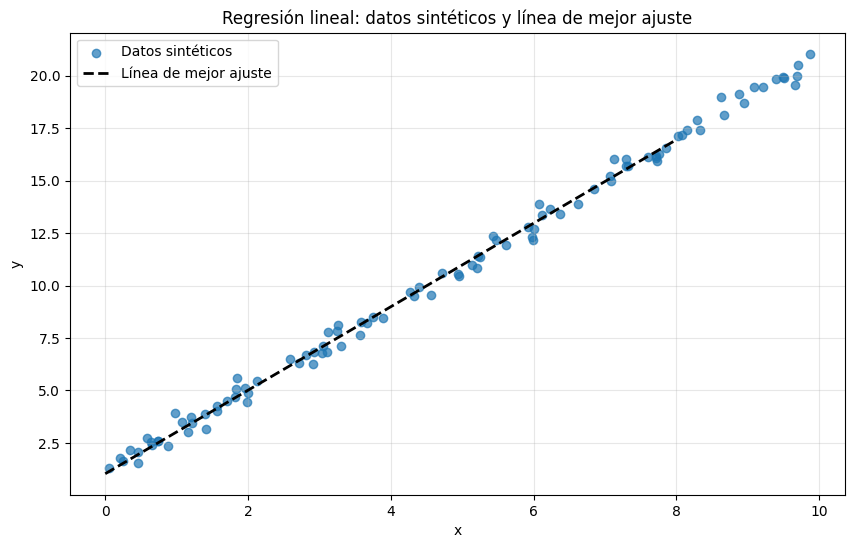

In [229]:
# Graficar puntos de datos y línea de mejor ajuste
x_plot = np.linspace(0, 8, 100).reshape(-1, 1).astype(np.float32)
y_plot = regression_model(x_plot).numpy()

plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data, alpha=0.7, label='Datos sintéticos')
plt.plot(x_plot, y_plot, 'k--', linewidth=2, label='Línea de mejor ajuste')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Regresión lineal: datos sintéticos y línea de mejor ajuste')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
# PROBLEMA 3
## Red neuronal para clasificación binaria (Iris)

Revisión del cuaderno DL_Tarea_1_PartII - Implementación desde cero con NumPy

In [230]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

np.random.seed(42)

In [231]:
import tensorflow as tf
print(f"TensorFlow: {tf.__version__}")
print(f"Keras: {tf.keras.__version__}")

TensorFlow: 2.19.0
Keras: 3.13.2


#**Paso 1: Carga y Preprocesamiento del Dataset Iris**
Cargamos el dataset Iris de Scikit-Learn. Para este problema de clasificación binaria, tomamos las dos primeras características (longitud y ancho del sépalo) y filtramos las etiquetas para separar la clase 'Setosa' de las demás. Reorganizamos las matrices para que tengan la forma (características, ejemplos), necesaria para nuestra implementación manual.

In [232]:
iris = datasets.load_iris()
X = iris.data[:, :2]
y = (iris.target != 0) * 1

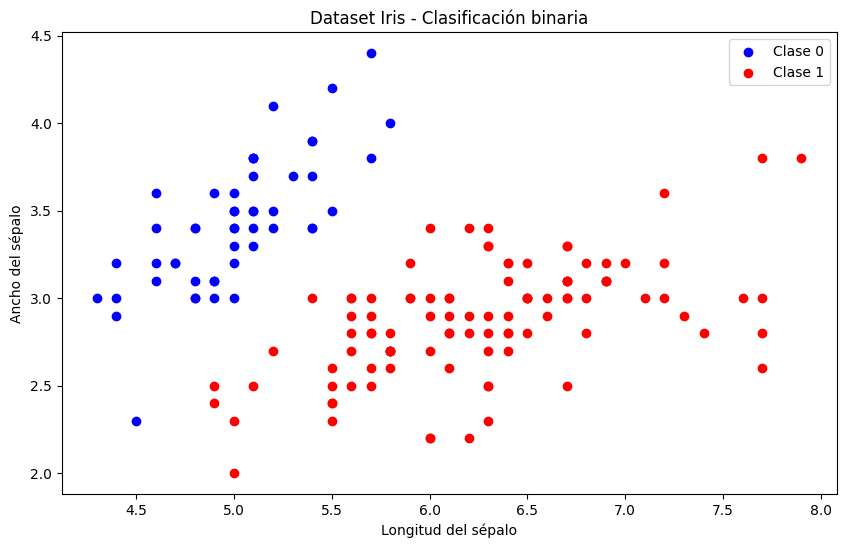

In [233]:
plt.figure(figsize=(10, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='b', label='Clase 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='r', label='Clase 1')
plt.legend()
plt.xlabel('Longitud del sépalo')
plt.ylabel('Ancho del sépalo')
plt.title('Dataset Iris - Clasificación binaria')
plt.show()

In [234]:
X = X.T
y = y.reshape(1, 150)
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (2, 150)
y shape: (1, 150)


**Implementación de funciones: sigmoid, forward/backward propagation, y entrenamiento**

#**Paso 2: Funciones de Activación y Estructura de la Red**
Definimos la función Sigmoide para la capa de salida y determinamos el tamaño de las capas: una capa de entrada (2 neuronas), una capa oculta (4 neuronas) y una capa de salida (1 neurona para clasificación binaria). Inicializamos los pesos (W) con valores pequeños aleatorios y los sesgos (b) en cero.

In [235]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def layer_sizes(X, Y):
    n_x = X.shape[0]
    n_h = 4
    n_y = Y.shape[0]
    return (n_x, n_h, n_y)

def initialize_parameters(n_x, n_h, n_y):
    np.random.seed(2)
    W1 = 0.01 * np.random.randn(n_h, n_x)
    b1 = np.zeros((n_h, 1))
    W2 = 0.01 * np.random.randn(n_y, n_h)
    b2 = np.zeros((n_y, 1))
    return {'W1': W1, 'b1': b1, 'W2': W2, 'b2': b2}

def forward_propagation(X, parameters):
    W1, b1 = parameters['W1'], parameters['b1']
    W2, b2 = parameters['W2'], parameters['b2']
    Z1 = np.dot(W1, X) + b1
    A1 = np.tanh(Z1)
    Z2 = np.dot(W2, A1) + b2
    A2 = sigmoid(Z2)
    cache = {'Z1': Z1, 'A1': A1, 'Z2': Z2, 'A2': A2}
    return A2, cache

def compute_cost(A2, Y, parameters):
    m = Y.shape[1]
    A2 = np.clip(A2, 1e-8, 1 - 1e-8)
    logprobs = np.multiply(np.log(A2), Y) + np.multiply(np.log(1 - A2), 1 - Y)
    return -np.sum(logprobs) / m

def backward_propagation(parameters, cache, X, Y):
    m = X.shape[1]
    W2 = parameters['W2']
    A1, A2 = cache['A1'], cache['A2']
    dZ2 = A2 - Y
    dW2 = (1/m) * np.dot(dZ2, A1.T)
    db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)
    dZ1 = np.dot(W2.T, dZ2) * (1 - np.power(A1, 2))
    dW1 = (1/m) * np.dot(dZ1, X.T)
    db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)
    return {'dW1': dW1, 'db1': db1, 'dW2': dW2, 'db2': db2}

def update_parameters(parameters, grads, learning_rate=1.2):
    parameters['W1'] -= learning_rate * grads['dW1']
    parameters['b1'] -= learning_rate * grads['db1']
    parameters['W2'] -= learning_rate * grads['dW2']
    parameters['b2'] -= learning_rate * grads['db2']
    return parameters

#**Paso 3: Forward Propagation y Función de Costo**
Implementamos la propagación hacia adelante utilizando la función Tanh para la capa oculta. Calculamos el costo utilizando la Entropía Cruzada Logarítmica, que mide la discrepancia entre las predicciones del modelo y las etiquetas reales.

In [236]:
def nn_model(X, Y, n_h, lr=1.2, num_iterations=10000, print_cost=False):
    np.random.seed(3)
    n_x, _, n_y = layer_sizes(X, Y)
    parameters = initialize_parameters(n_x, n_h, n_y)
    for i in range(num_iterations):
        A2, cache = forward_propagation(X, parameters)
        cost = compute_cost(A2, Y, parameters)
        grads = backward_propagation(parameters, cache, X, Y)
        parameters = update_parameters(parameters, grads, learning_rate=lr)
        if print_cost and i % 1000 == 0:
            print(f"Cost after iteration {i}: {cost:.4f}")
    return parameters

#**Paso 4: Aprendizaje mediante Backward Propagation**
Calculamos los gradientes utilizando la regla de la cadena para determinar cómo cada peso y sesgo afecta al error. Luego, actualizamos los parámetros restando el gradiente multiplicado por la tasa de aprendizaje (learning rate). Este proceso se repite durante 10,000 iteraciones para minimizar el costo.

In [237]:
parameters = nn_model(X, y, n_h=4, lr=0.3, num_iterations=10000, print_cost=True)

Cost after iteration 0: 0.6930
Cost after iteration 1000: 0.0259
Cost after iteration 2000: 0.0156
Cost after iteration 3000: 0.0090
Cost after iteration 4000: 0.0059
Cost after iteration 5000: 0.0044
Cost after iteration 6000: 0.0034
Cost after iteration 7000: 0.0028
Cost after iteration 8000: 0.0023
Cost after iteration 9000: 0.0020


#**Paso 5: Predicción y Evaluación Final**
Utilizamos el modelo entrenado para generar predicciones sobre el conjunto de datos. Convertimos la probabilidad de salida en una etiqueta binaria (0 o 1) usando un umbral de 0.5 y calculamos la precisión final del modelo.

In [238]:
def predict(parameters, X):
    A2, _ = forward_propagation(X, parameters)
    return (A2 > 0.5)

predictions = predict(parameters, X)
accuracy = np.mean((predictions == y).astype(float)) * 100
print(f"Precisión en entrenamiento: {accuracy:.2f}%")

Precisión en entrenamiento: 100.00%
